# 05 Links to Other Indices

Compares the DPI against two external benchmarks:
1. Official FIA Championship Standings - Spearman rank correlation per season
2. OpenF1 lap telemetry - average gap to session fastest lap as an 
   independent pace metric for 2023 and 2024



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

norm_df = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')

print("Shape:", norm_df.shape)
print("\nColumns:", list(norm_df.columns))

Shape: (105, 24)

Columns: ['season', 'driver_id', 'driver_code', 'driver_name', 'constructor', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position', 'cluster', 'cluster_label', 'DPI', 'DPI_rank', 'official_rank', 'DPI_rank_season', 'rank_diff']


## Part 1: DPI vs Official FIA Championship Standings

The Spearman rank correlation coefficient measures how closely the DPI 
ranking agrees with the official FIA championship ranking each season. 
A value of 1 means perfect agreement, 0 means no relationship. 
Spearman is used rather than Pearson because we are comparing ranks 
rather than raw values.

In [3]:
results = []
for season in sorted(norm_df['season'].unique()):
    season_data = norm_df[norm_df['season'] == season].dropna()
    r, p = spearmanr(
        season_data['official_rank'],
        season_data['DPI_rank_season']
    )
    results.append({
        'season'    : season,
        'spearman_r': round(r, 3),
        'p_value'   : round(p, 4),
        'n_drivers' : len(season_data)
    })

spearman_df = pd.DataFrame(results)
print("Spearman Correlation — DPI vs Official FIA Standings:")
print(spearman_df.to_string(index=False))

Spearman Correlation — DPI vs Official FIA Standings:
 season  spearman_r  p_value  n_drivers
   2021       0.959      0.0         20
   2022       0.919      0.0         20
   2023       0.936      0.0         22
   2024       0.894      0.0         22
   2025       0.906      0.0         21


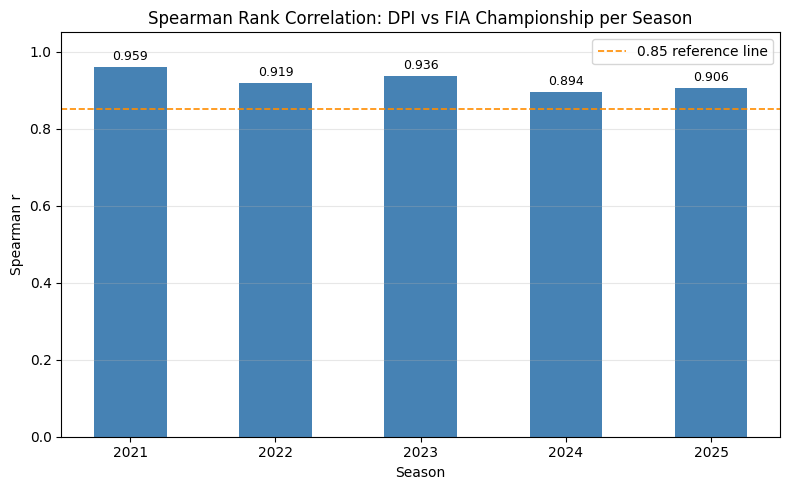

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    spearman_df['season'],
    spearman_df['spearman_r'],
    color='steelblue', width=0.5
)
ax.axhline(0.85, linestyle='--', color='darkorange',
           linewidth=1.2, label='0.85 reference line')
ax.set_ylim(0, 1.05)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Spearman Rank Correlation: DPI vs FIA Championship per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Spearman r')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'spearman_by_season.png', dpi=150)
plt.show()